In [40]:
import os
import pathlib
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

In [41]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
# Ruta archivo CSV
file_path = Path(
    r"C:\Users\juans\OneDrive\Documentos\Maestria en Ingenieria y Analitica de Datos\Proyecto de Grado\CineMate AI\data\raw\chatbot_sessions_raw.csv"
)

# Cargar CSV
df_results = pd.read_csv(file_path, encoding="utf-8-sig")

# Validación rápida
print("Archivo cargado correctamente")
print("Filas:", df_results.shape[0])
print("Columnas:", df_results.shape[1])

# Vista previa
df_results.head()

Archivo cargado correctamente
Filas: 339
Columnas: 24


,session_id,user_id,created_at,session_mode,session_use_rag,interaction_number,timestamp,query,routed_query,mode,...,title_response,score_response,csat_score,nps_score,resolution_numeric,csat_category,nps_category,resolution_label,Total,Surveys
0,40cf9414-6b0c-4b55-a80f-7e205d1fcf91,57 312 5489784,4/22/2026,RAG,True,1,19:16,Películas de comedia divertidas,Películas de comedia divertidas,RAG,...,Pelé: Birth of a Legend,0.0548,2,3,1,Baja,detractor,no,1,1
1,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,1,2:39,recomienda me novelas como sin senos si hay pa...,recomienda me novelas como sin senos si hay pa...,RAG,...,Trilussa - Storia d'amore e di poesia,0.1342,5,7,1,Alta,passive,no,1,1
2,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,2,2:45,una novela que sea de colombia,una novela que sea de colombia,RAG,...,El Señor de los Cielos,0.2524,5,7,1,Alta,passive,no,1,1
3,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,3,2:51,y series de colombia como sin senos si hay par...,y series de colombia como sin senos si hay par...,RAG,...,Juanpis González - The Series,0.3509,5,7,1,Alta,passive,no,1,1
4,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,4,3:07,y una parecida a la reina del flow,y una parecida a la reina del flow,RAG,...,Flow,0.2484,5,7,1,Alta,passive,no,1,1


In [43]:
def load_and_prepare_dataset(path):
    """
    Carga el dataset y transforma genres y keywords a listas
    """

    # -------------------------
    # 1. Cargar dataset
    # -------------------------
    df = pd.read_csv(path,encoding="utf-8-sig")

    print(f"Dataset cargado: {df.shape}")

    # -------------------------
    # 2. Función para convertir a lista
    # -------------------------
    def split_pipe_to_list(text):
        if pd.isna(text) or text == "":
            return []
        
        return [item.strip() for item in text.split("|") if item.strip()]

    # -------------------------
    # 3. Aplicar transformación
    # -------------------------
    if "genres" in df.columns:
        df["genres"] = df["genres"].apply(split_pipe_to_list)

    if "keywords" in df.columns:
        df["keywords"] = df["keywords"].apply(split_pipe_to_list)

    print("Transformación completada ✅")

    return df

In [44]:
# Ruta archivo CSV
file_path = Path(
    r"C:\Users\juans\OneDrive\Documentos\Maestria en Ingenieria y Analitica de Datos\Proyecto de Grado\CineMate AI\data\raw\tmdb_movies_dataset.csv"
)

# Cargar CSV
df_movies = load_and_prepare_dataset(file_path)

# Validación rápida
print("Archivo cargado correctamente")
print("Filas:", df_movies.shape[0])
print("Columnas:", df_movies.shape[1])

# Vista previa
df_movies.head()

Dataset cargado: (20000, 9)
Transformación completada ✅
Archivo cargado correctamente
Filas: 20000
Columnas: 9


,url,title,release_date,age_rating,runtime_minutes,genres,overview,score,keywords
0,https://www.themoviedb.org/movie/1265609-war-m...,War Machine,03/06/2026,MA 15+,110.0,"[Action, Science Fiction, Thriller]",On one last grueling mission during Army Range...,73,"[military training, military sci-fi, u.s. army..."
1,https://www.themoviedb.org/movie/1290821-shelter,Shelter,01/30/2026,15,107.0,"[Action, Crime, Thriller]",A man living in self-imposed exile on a remote...,67,"[grave, ghosts of the past, apologetic, solita..."
2,https://www.themoviedb.org/movie/799882-the-bluff,The Bluff,02/17/2026,R,102.0,"[Action, Thriller]",When her tranquil life on a remote island is s...,63,"[pirate, sister-in-law, caribbean sea, aggress..."
3,https://www.themoviedb.org/movie/1193501-whistle,Whistle,02/12/2026,R,100.0,"[Horror, Mystery]",A misfit group of unwitting high school studen...,61,"[grave, high school, evil spirit, school, deat..."
4,https://www.themoviedb.org/movie/680493-return...,Return to Silent Hill,01/29/2026,15,106.0,"[Mystery, Drama, Horror]",When James receives a mysterious letter from h...,50,"[painter, monster, letter, wife, supernatural,..."


In [45]:
df_analysis = df_results.merge(
    df_movies[
        [
            "title",
            "genres",
            "keywords",
            "overview",
            "score",
            "release_date",
        ]
    ],
    how="left",
    left_on="title_response",
    right_on="title",
)


# hallucination = movie not found in movie dataset
df_analysis["hallucination"] = np.where(
    df_analysis["title"].isna(),
    1,
    0,
)

# valid movie recommendation
df_analysis["valid_movie"] = np.where(
    df_analysis["title"].notna(),
    1,
    0,
)

# rag vs no rag label
df_analysis["rag_mode"] = np.where(
    df_analysis["use_rag"] == True,
    "RAG",
    "NO_RAG",
)


print(df_analysis.shape)

df_analysis.head()

(352, 33)


,session_id,user_id,created_at,session_mode,session_use_rag,interaction_number,timestamp,query,routed_query,mode,...,Surveys,title,genres,keywords,overview,score,release_date,hallucination,valid_movie,rag_mode
0,40cf9414-6b0c-4b55-a80f-7e205d1fcf91,57 312 5489784,4/22/2026,RAG,True,1,19:16,Películas de comedia divertidas,Películas de comedia divertidas,RAG,...,1,Pelé: Birth of a Legend,[Drama],"[biography, sports, football (soccer), brazil,...","The life story of Brazilian football legend, P...",73,05/06/2016,0,1,RAG
1,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,1,2:39,recomienda me novelas como sin senos si hay pa...,recomienda me novelas como sin senos si hay pa...,RAG,...,1,Trilussa - Storia d'amore e di poesia,[Drama],[],"Biographical movie on the life of Trilussa, ak...",63,03/11/2013,0,1,RAG
2,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,2,2:45,una novela que sea de colombia,una novela que sea de colombia,RAG,...,1,El Señor de los Cielos,"[Crime, Drama, Soap]","[drug trafficking, drug cartel, drug lord, tel...","Set in the 1990s, these are the life and times...",79,NaN,0,1,RAG
3,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,3,2:51,y series de colombia como sin senos si hay par...,y series de colombia como sin senos si hay par...,RAG,...,1,Juanpis González - The Series,"[Comedy, Drama]","[beach, politics, vacation, love, irreverent]",A Colombian snob forays into the uncharted ter...,75,NaN,0,1,RAG
4,cd7d7ecd-83f1-4ba5-8adb-9c26f84632dd,57 317 8517661,4/19/2026,RAG,True,4,3:07,y una parecida a la reina del flow,y una parecida a la reina del flow,RAG,...,1,Flow,"[Animation, Adventure, Fantasy, Family]","[ocean, cat, boat, dystopia, dog, ruins, flood...","A solitary cat, displaced by a great flood, fi...",81,02/20/2025,0,1,RAG


In [46]:
df_analysis.to_csv(
    r"C:\Users\juans\OneDrive\Documentos\Maestria en Ingenieria y Analitica de Datos\Proyecto de Grado\CineMate AI\data\raw\survey_analysis.csv",
    index=False)

### Comparación mediante métricas internas

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

<Figure size 800x600 with 0 Axes>

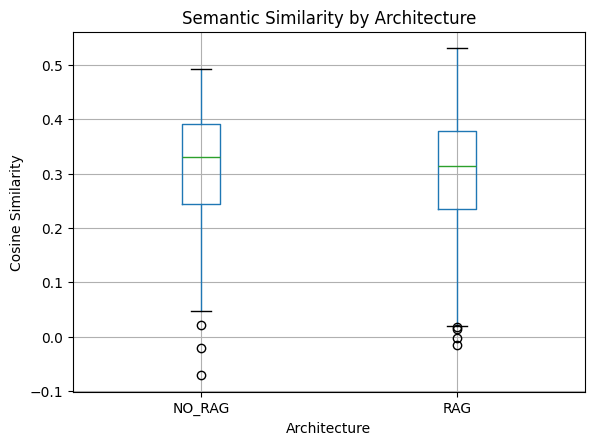

rag_mode
NO_RAG    0.304972
RAG       0.299263
Name: semantic_similarity, dtype: float32


In [47]:
def safe_to_text(value):

    if value is None:
        return ""

    if isinstance(value, float) and np.isnan(value):
        return ""

    if isinstance(value, (list, tuple, np.ndarray)):
        return " ".join(map(str, value))

    return str(value)

df_analysis["semantic_text"] = (
    df_analysis["genres"].apply(safe_to_text) + " " +
    df_analysis["keywords"].apply(safe_to_text) + " " +
    df_analysis["overview"].apply(safe_to_text)
)

query_embeddings = model.encode(
    df_analysis["query"].astype(str).tolist(),
    show_progress_bar=True
)

movie_embeddings = model.encode(
    df_analysis["semantic_text"].astype(str).tolist(),
    show_progress_bar=True
)

similarities = []

for q_emb, m_emb in zip(query_embeddings, movie_embeddings):

    similarity = cosine_similarity(
        [q_emb],
        [m_emb]
    )[0][0]

    similarities.append(similarity)

df_analysis["semantic_similarity"] = similarities

df_analysis["rag_mode"] = np.where(
    df_analysis["use_rag"] == True,
    "RAG",
    "NO_RAG",
)

plt.figure(figsize=(8,6))

df_analysis.boxplot(
    column="semantic_similarity",
    by="rag_mode"
)

plt.title("Semantic Similarity by Architecture")
plt.suptitle("")

plt.xlabel("Architecture")
plt.ylabel("Cosine Similarity")

plt.show()

print(
    df_analysis
    .groupby("rag_mode")["semantic_similarity"]
    .mean()
)

Análisis de Similaridad Semántica

Comparar qué tan relacionadas son las recomendaciones generadas por RAG y No-RAG con respecto a las consultas realizadas por los usuarios.

Los resultados muestran un comportamiento bastante similar entre ambas arquitecturas, con valores de similaridad cercanos entre sí. Aunque NO_RAG presenta un promedio ligeramente superior, RAG alcanza algunos valores máximos más altos, lo que indica que en ciertos casos logró recomendaciones más alineadas con el contexto de la consulta.

          semantic_similarity  latency_min
rag_mode                                  
NO_RAG               0.304972     7.343488
RAG                  0.299263     7.718801


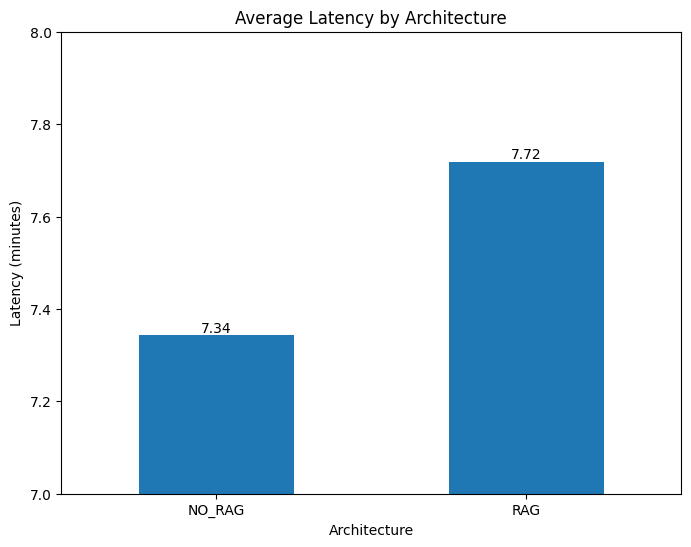

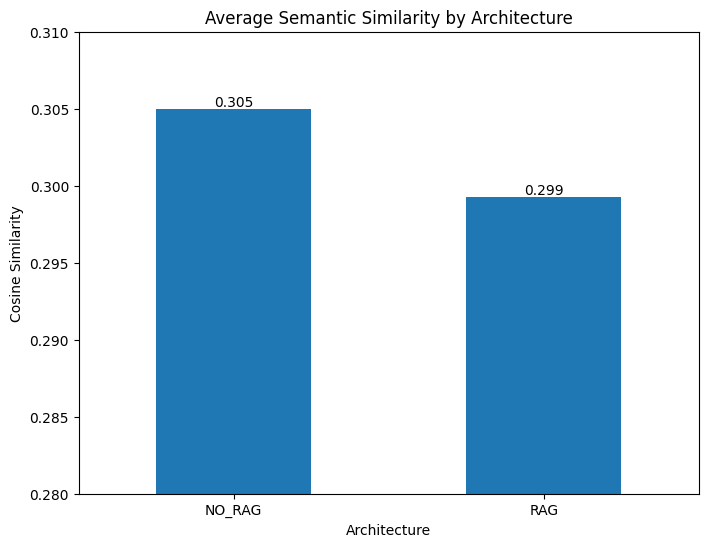

In [48]:
summary_metrics = (
    df_analysis
    .groupby("rag_mode")
    .agg({
        "semantic_similarity": "mean",
        "latency_min": "mean"
    })
)

print(summary_metrics)

ax = summary_metrics["latency_min"].plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Average Latency by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Latency (minutes)")

plt.ylim(7.0, 8.0)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

ax = summary_metrics["semantic_similarity"].plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Average Semantic Similarity by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Cosine Similarity")

plt.ylim(0.28, 0.31)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

Análisis de Latencia y Calidad Semántica

Objetivo:
Comparar el tiempo de respuesta y la calidad semántica de las recomendaciones generadas por las arquitecturas RAG y No-RAG.

Los resultados muestran que la arquitectura RAG presentó una latencia ligeramente superior debido al proceso adicional de recuperación contextual. Sin embargo, ambas arquitecturas mantuvieron niveles de similaridad semántica muy cercanos, evidenciando un comportamiento comparable en la calidad de las recomendaciones generadas.

          Precision@K  Recall@K
rag_mode                       
NO_RAG       0.434524   0.52518
RAG          0.358696   0.47482


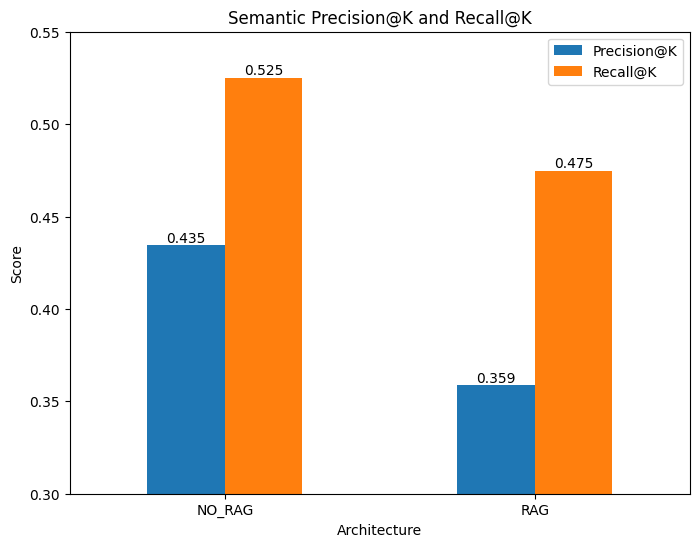

In [49]:
THRESHOLD = 0.35

# relevance based on semantic similarity
df_analysis["relevant"] = np.where(
    df_analysis["semantic_similarity"] >= THRESHOLD,
    1,
    0,
)

precision_at_k = (
    df_analysis
    .groupby("rag_mode")["relevant"]
    .mean()
)
total_relevant = df_analysis["relevant"].sum()

recall_at_k = (
    df_analysis
    .groupby("rag_mode")["relevant"]
    .sum()
    / total_relevant
)

metrics_df = pd.DataFrame({
    "Precision@K": precision_at_k,
    "Recall@K": recall_at_k
})

print(metrics_df)

ax = metrics_df.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Semantic Precision@K and Recall@K")
plt.xlabel("Architecture")
plt.ylabel("Score")

# Adjust Y-axis scale
plt.ylim(0.30, 0.55)

plt.xticks(rotation=0)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

Análisis de Precision@K y Recall@K

Objetivo:
Evaluar la capacidad de las arquitecturas RAG y No-RAG para generar recomendaciones semánticamente relevantes a partir de las consultas realizadas por los usuarios.

Los resultados muestran que la arquitectura NO_RAG obtuvo valores ligeramente superiores en Precision@K y Recall@K. Esto indica que, para el conjunto de consultas evaluadas, las recomendaciones generadas sin retrieval contextual presentaron una mayor coincidencia semántica promedio con las consultas realizadas. Sin embargo, las diferencias entre ambas arquitecturas no son considerablemente amplias.

### Comparación por tipo de consulta

In [50]:
genre_keywords = [

    "acción",
    "comedia",
    "drama",
    "terror",
    "thriller",
    "romance",
    "ciencia ficción",
    "fantasía",
    "misterio",
    "crimen",
    "aventura",
    "animación",
    "familia",
    "guerra",
    "documental"

]

emotional_keywords = [

    "triste",
    "emocional",
    "oscura",
    "profunda",
    "desgarradora",
    "motivadora",
    "inspiradora",
    "romántica",
    "psicológica",
    "dramática",
    "intensa"

]

title_patterns = [

    "como",
    "similar a",
    "parecida a",
    "películas como",
    "parecido a"

]

def classify_query(query):

    if pd.isna(query):
        return "unknown"

    query = str(query).lower()

    if any(pattern in query for pattern in title_patterns):
        return "title_search"

    if any(word in query for word in emotional_keywords):
        return "emotional_search"

    if any(word in query for word in genre_keywords):
        return "genre_search"

    if len(query.split()) >= 6:
        return "complex_search"

    return "complex_search"

df_analysis["query_type"] = df_analysis["query"].apply(classify_query)

print(
    df_analysis["query_type"].value_counts()
)

display(
    df_analysis[
        [
            "query",
            "query_type"
        ]
    ].head(20)
)

query_type
complex_search      187
genre_search         99
title_search         46
emotional_search     20
Name: count, dtype: int64


,query,query_type
0,Películas de comedia divertidas,genre_search
1,recomienda me novelas como sin senos si hay pa...,title_search
2,una novela que sea de colombia,complex_search
3,y series de colombia como sin senos si hay par...,title_search
4,y una parecida a la reina del flow,title_search
5,lista de películas de acción mas vistas,genre_search
6,mejores películas de ciencia ficción,genre_search
7,si,complex_search
8,drama,genre_search
9,recomienda algo parecido a harry potte,title_search


,query_type,rag_mode,semantic_similarity
0,complex_search,NO_RAG,0.291529
1,complex_search,RAG,0.291647
2,emotional_search,NO_RAG,0.378293
3,emotional_search,RAG,0.350139
4,genre_search,NO_RAG,0.330121
5,genre_search,RAG,0.312769
6,title_search,NO_RAG,0.267471
7,title_search,RAG,0.281178


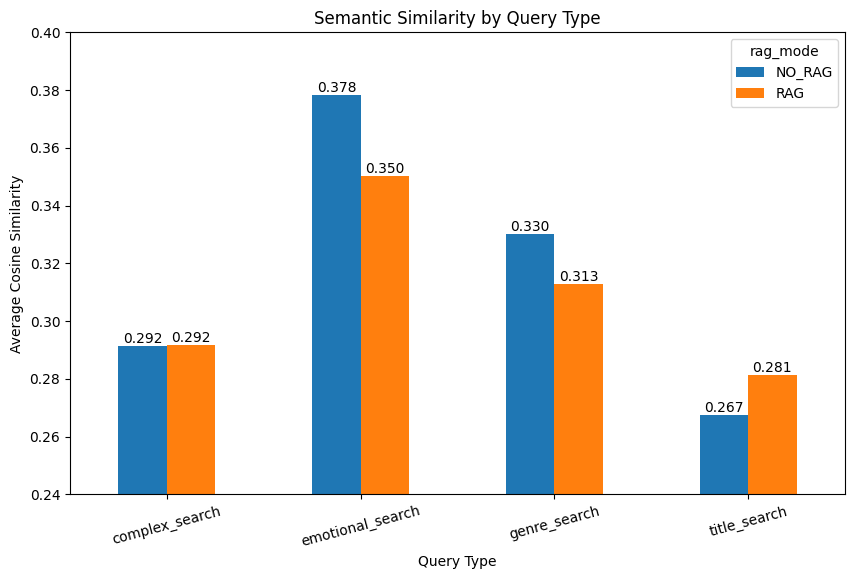

In [51]:
avg_similarity_by_type = (

    df_analysis
    .groupby(
        ["query_type", "rag_mode"]
    )["semantic_similarity"]
    .mean()
    .reset_index()

)

display(avg_similarity_by_type)

pivot_similarity = avg_similarity_by_type.pivot(
    index="query_type",
    columns="rag_mode",
    values="semantic_similarity"
)

ax = pivot_similarity.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Semantic Similarity by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Average Cosine Similarity")

# Adjust Y-axis scale
plt.ylim(0.24, 0.40)

plt.xticks(rotation=15)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

Similaridad Semántica por Tipo de Consulta

Objetivo:
Comparar el desempeño de las arquitecturas RAG y No-RAG según el tipo de consulta realizada por los usuarios.

Insight:
Los resultados muestran que ambas arquitecturas presentan un comportamiento muy similar en las consultas complejas. Sin embargo, NO_RAG obtuvo mejores resultados en búsquedas emocionales y por género, mientras que RAG mostró una ligera ventaja en búsquedas por título. Esto sugiere que el retrieval contextual puede aportar mayor valor en consultas específicas relacionadas con referencias directas a películas.

,query_type,rag_gain
0,complex_search,0.000118
1,emotional_search,-0.028155
2,genre_search,-0.017352
3,title_search,0.013707


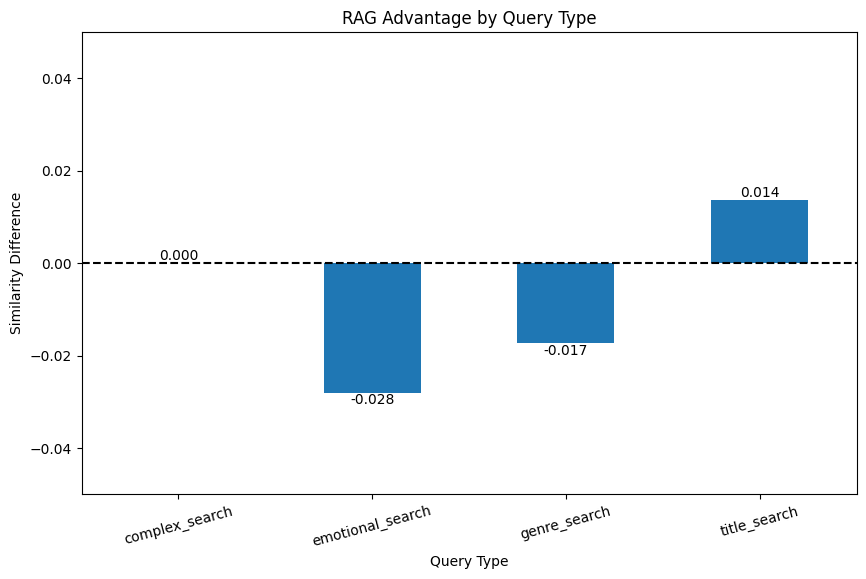

In [52]:
rag_advantage = (

    pivot_similarity["RAG"]
    - pivot_similarity["NO_RAG"]

).reset_index()

rag_advantage.columns = [
    "query_type",
    "rag_gain"
]

display(rag_advantage)

ax = rag_advantage.plot(
    x="query_type",
    y="rag_gain",
    kind="bar",
    figsize=(10,6),
    legend=False
)

plt.title("RAG Advantage by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Similarity Difference")

# Adjust Y-axis scale
plt.ylim(-0.05, 0.05)

plt.xticks(rotation=15)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.show()

Ventaja Comparativa de RAG por Tipo de Consulta

Objetivo:
Identificar en qué tipos de consultas la arquitectura RAG presenta ventajas frente al enfoque No-RAG.

Insight:
Los resultados muestran que la mayor ventaja de RAG se presentó en las búsquedas por título, donde obtuvo una mejora positiva en similaridad semántica. En las consultas complejas ambas arquitecturas tuvieron un desempeño prácticamente igual. Por otro lado, NO_RAG presentó mejores resultados en búsquedas emocionales y por género, evidenciando que el retrieval contextual no siempre genera mejoras significativas dependiendo del tipo de consulta realizada.

,query_type,rag_mode,semantic_similarity,latency_min
0,complex_search,NO_RAG,0.291529,7.506779
1,complex_search,RAG,0.291647,7.573341
2,emotional_search,NO_RAG,0.378293,7.628656
3,emotional_search,RAG,0.350139,6.671061
4,genre_search,NO_RAG,0.330121,6.564891
5,genre_search,RAG,0.312769,5.988785
6,title_search,NO_RAG,0.267471,8.582390
7,title_search,RAG,0.281178,11.822635


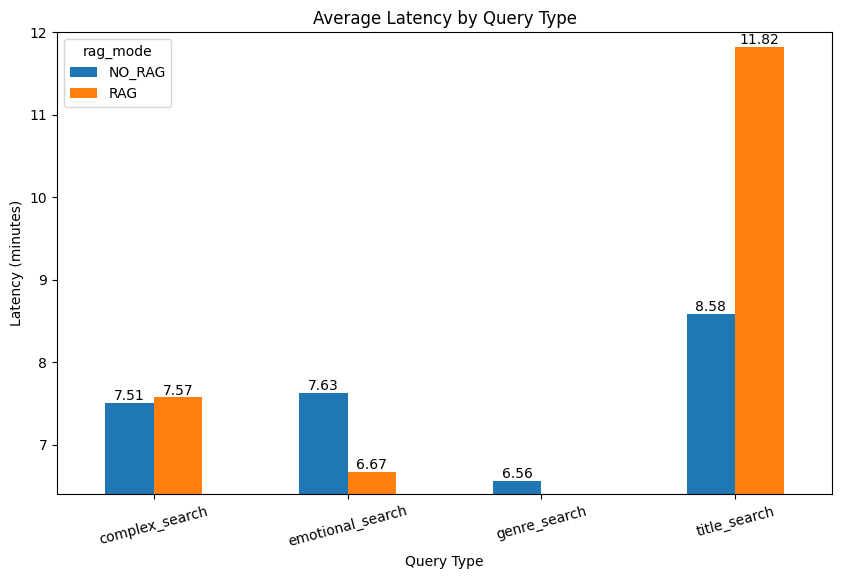

In [53]:
query_type_summary = (

    df_analysis
    .groupby(
        ["query_type", "rag_mode"]
    )
    .agg({
        "semantic_similarity": "mean",
        "latency_min": "mean"
    })
    .reset_index()

)

display(query_type_summary)

pivot_latency = query_type_summary.pivot(
    index="query_type",
    columns="rag_mode",
    values="latency_min"
)

ax = pivot_latency.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Latency by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Latency (minutes)")

# Better scale
plt.ylim(6.4, 12)

plt.xticks(rotation=15)

# Labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

Latencia Promedio por Tipo de Consulta

Objetivo:
Comparar el tiempo de respuesta de las arquitecturas RAG y No-RAG según el tipo de consulta realizada por los usuarios.

Insight:
Los resultados muestran diferencias de latencia entre ambos enfoques dependiendo del tipo de consulta. RAG presentó el mayor tiempo de respuesta en las búsquedas por título, mientras que en las consultas emocionales obtuvo tiempos inferiores a NO_RAG. En las búsquedas complejas ambas arquitecturas mantuvieron tiempos similares, evidenciando un comportamiento relativamente estable en consultas semánticas más avanzadas.

,query_type,rag_mode,semantic_similarity,latency_min,csat_score
0,complex_search,NO_RAG,0.291529,7.506779,3.494253
1,complex_search,RAG,0.291647,7.573341,3.700000
2,emotional_search,NO_RAG,0.378293,7.628656,3.625000
3,emotional_search,RAG,0.350139,6.671061,3.583333
4,genre_search,NO_RAG,0.330121,6.564891,3.037736
5,genre_search,RAG,0.312769,5.988785,3.543478
6,title_search,NO_RAG,0.267471,8.582390,4.000000
7,title_search,RAG,0.281178,11.822635,4.076923


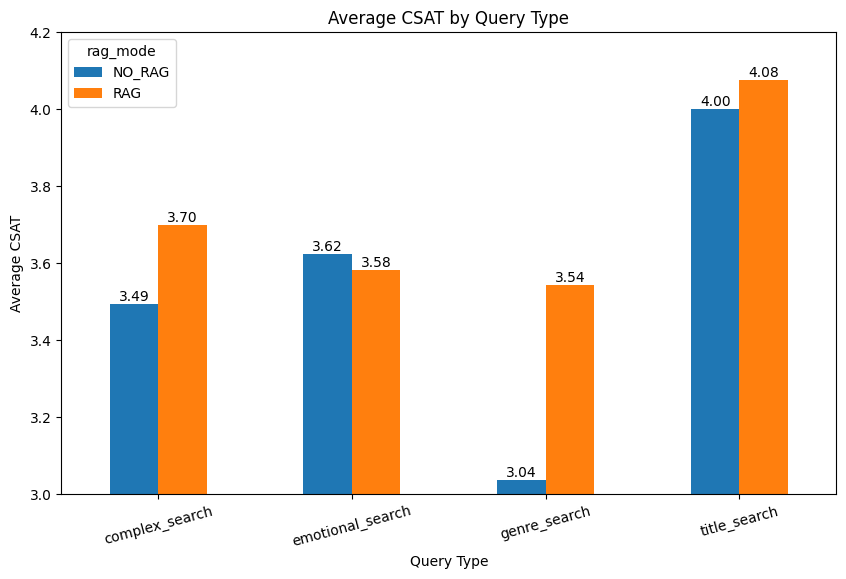

In [54]:
final_query_analysis = (

    df_analysis
    .groupby(
        ["query_type", "rag_mode"]
    )
    .agg({
        "semantic_similarity": "mean",
        "latency_min": "mean",
        "csat_score": "mean"
    })
    .reset_index()

)

display(final_query_analysis)

pivot_csat = final_query_analysis.pivot(
    index="query_type",
    columns="rag_mode",
    values="csat_score"
)

ax = pivot_csat.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average CSAT by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Average CSAT")

# Adjust scale
plt.ylim(3.0, 4.2)

plt.xticks(rotation=15)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

CSAT Promedio por Tipo de Consulta

Objetivo:
Comparar el nivel de satisfacción de los usuarios entre las arquitecturas RAG y No-RAG según el tipo de consulta realizada.

Insight:
Los resultados muestran que la arquitectura RAG obtuvo mayores niveles de satisfacción en las búsquedas complejas, por género y por título. La mayor diferencia se presentó en las búsquedas por género, donde RAG superó notablemente a NO_RAG. En las consultas emocionales, ambas arquitecturas mantuvieron valores de satisfacción similares, evidenciando una percepción comparable por parte de los usuarios.

### Comparación mediante satisfacción del usuario

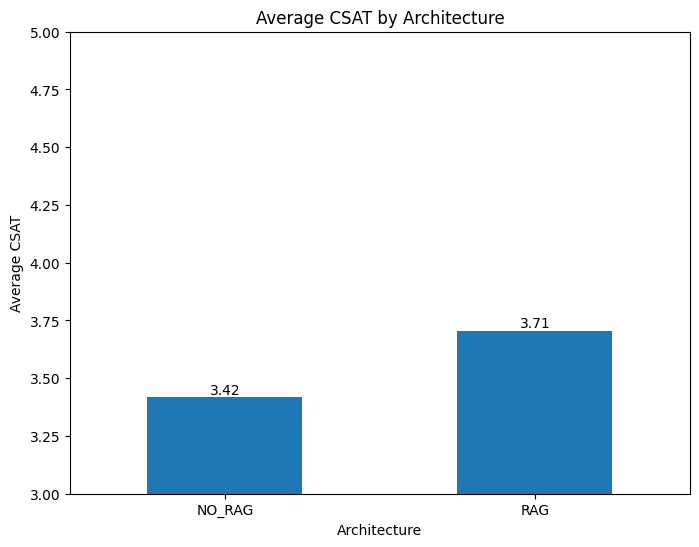

In [55]:
avg_csat = (

    df_analysis
    .groupby("rag_mode")["csat_score"]
    .mean()

)

ax = avg_csat.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Average CSAT by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Average CSAT")

plt.ylim(3.0, 5.0)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

CSAT Promedio por Arquitectura

Objetivo:
Comparar el nivel de satisfacción promedio de los usuarios entre las arquitecturas RAG y No-RAG.

Insight:
Los resultados muestran que la arquitectura RAG obtuvo un mayor nivel de satisfacción promedio en comparación con NO_RAG. Esto sugiere que, aunque las diferencias técnicas entre ambas arquitecturas no siempre fueron significativas, los usuarios percibieron una mejor experiencia y calidad en las recomendaciones generadas mediante retrieval contextual.

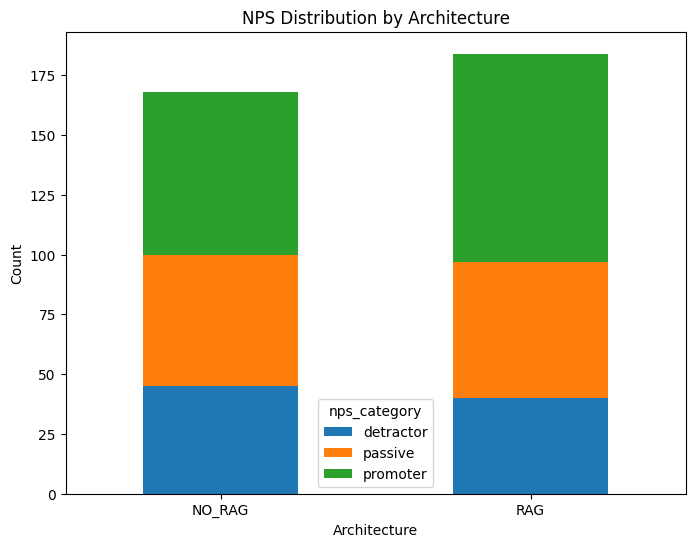

In [56]:
nps_distribution = (

    df_analysis
    .groupby(
        ["rag_mode", "nps_category"]
    )
    .size()
    .unstack(fill_value=0)

)

ax = nps_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("NPS Distribution by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

Distribución NPS por Arquitectura

Objetivo:
Analizar la percepción de recomendación de los usuarios entre las arquitecturas RAG y No-RAG mediante la clasificación NPS.

Insight:
Los resultados muestran que la arquitectura RAG obtuvo una mayor cantidad de usuarios clasificados como promoters y una menor proporción de detractors en comparación con NO_RAG. Esto evidencia una mejor percepción general por parte de los usuarios hacia las recomendaciones generadas utilizando retrieval contextual.

rag_mode
NO_RAG    2.083333
RAG       2.157609
Name: resolution_numeric, dtype: float64


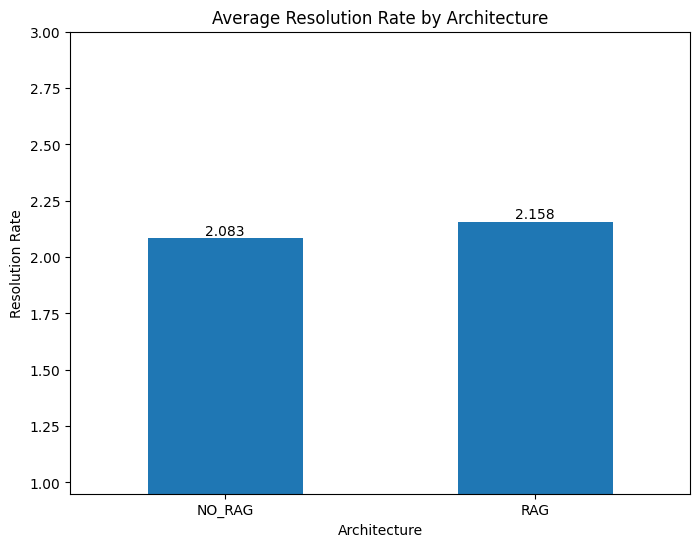

In [61]:
avg_resolution = (

    df_analysis
    .groupby("rag_mode")["resolution_numeric"]
    .mean()

)

print(avg_resolution)

ax = avg_resolution.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Average Resolution Rate by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Resolution Rate")

# Better scale
plt.ylim(0.95, 3)

plt.xticks(rotation=0)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

Resolution Rate Promedio por Arquitectura

Objetivo:
Comparar el nivel de resolución percibida por los usuarios entre las arquitecturas RAG y No-RAG.

Insight:
Los resultados muestran que la arquitectura RAG obtuvo un nivel de resolución ligeramente superior al enfoque NO_RAG. Esto indica que los usuarios percibieron una mayor capacidad de respuesta y cumplimiento de sus necesidades cuando las recomendaciones fueron generadas utilizando retrieval contextual.

### Relación entre métricas técnicas y satisfacción

,semantic_similarity,latency_min,csat_score,nps_score,resolution_numeric
semantic_similarity,1.000000,-0.085237,0.154533,0.126505,0.173396
latency_min,-0.085237,1.000000,-0.088713,-0.103034,-0.093717
csat_score,0.154533,-0.088713,1.000000,0.881377,0.875017
nps_score,0.126505,-0.103034,0.881377,1.000000,0.928277
resolution_numeric,0.173396,-0.093717,0.875017,0.928277,1.000000


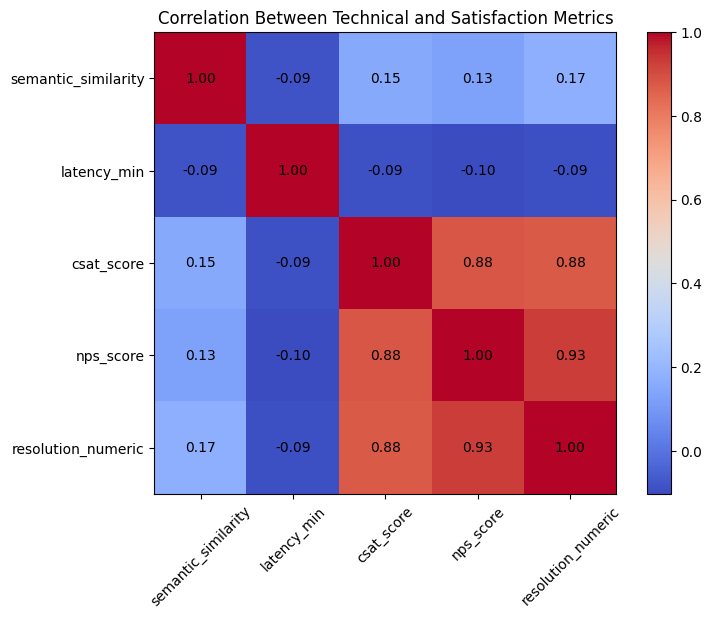

In [67]:
correlation_metrics = df_analysis[
    [
        "semantic_similarity",
        "latency_min",
        "csat_score",
        "nps_score",
        "resolution_numeric"
    ]
].corr()

display(correlation_metrics)

fig, ax = plt.subplots(figsize=(8,6))

heatmap = ax.imshow(
    correlation_metrics,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(heatmap)

ax.set_xticks(range(len(correlation_metrics.columns)))
ax.set_yticks(range(len(correlation_metrics.columns)))

ax.set_xticklabels(
    correlation_metrics.columns,
    rotation=45
)

ax.set_yticklabels(
    correlation_metrics.columns
)

# Add correlation values inside cells
for i in range(len(correlation_metrics.columns)):
    for j in range(len(correlation_metrics.columns)):

        value = correlation_metrics.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Between Technical and Satisfaction Metrics")

plt.show()

Correlación entre Métricas Técnicas y de Satisfacción

Objetivo:
Analizar la relación entre las métricas técnicas del sistema y la percepción de satisfacción de los usuarios.

Insight:
Los resultados muestran una fuerte correlación positiva entre CSAT, NPS y Resolution Rate, indicando que los usuarios que percibieron una mejor resolución también reportaron mayores niveles de satisfacción y recomendación. Por otro lado, la latencia presentó una correlación baja o negativa con las métricas de satisfacción, sugiriendo que tiempos de respuesta más altos no necesariamente mejoran la experiencia del usuario. La similaridad semántica mostró una relación moderada con las métricas de satisfacción, evidenciando que la calidad contextual de las recomendaciones puede influir positivamente en la percepción del sistema.

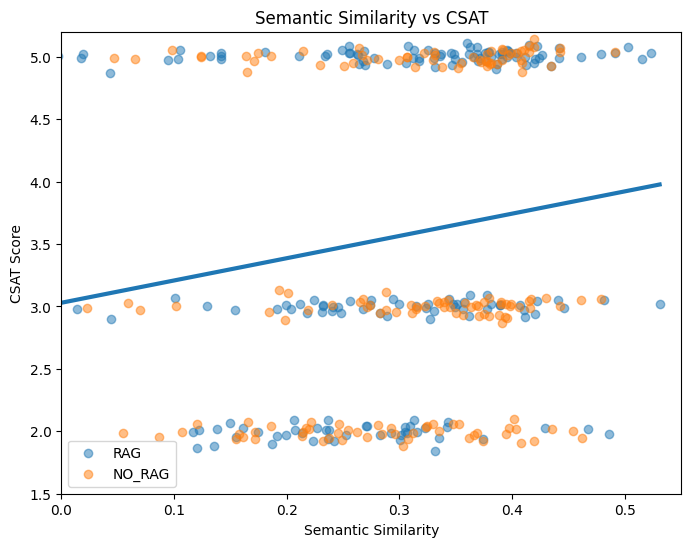

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(
    rag_data["semantic_similarity"],
    rag_data["csat_score"] + np.random.normal(0, 0.05, len(rag_data)),
    alpha=0.5,
    label="RAG"
)

plt.scatter(
    no_rag_data["semantic_similarity"],
    no_rag_data["csat_score"] + np.random.normal(0, 0.05, len(no_rag_data)),
    alpha=0.5,
    label="NO_RAG"
)

# Linear regression
z = np.polyfit(
    df_analysis["semantic_similarity"],
    df_analysis["csat_score"],
    1
)

p = np.poly1d(z)

# Sort X values
x_sorted = np.sort(
    df_analysis["semantic_similarity"]
)

plt.plot(
    x_sorted,
    p(x_sorted),
    linewidth=3
)

plt.title("Semantic Similarity vs CSAT")
plt.xlabel("Semantic Similarity")
plt.ylabel("CSAT Score")

plt.xlim(0.0, 0.55)
plt.ylim(1.5, 5.2)

plt.legend()

plt.show()

Similaridad Semántica vs CSAT

Objetivo:
Analizar la relación entre la calidad semántica de las recomendaciones y el nivel de satisfacción percibido por los usuarios.

Insight:
Los resultados muestran una tendencia positiva entre la similaridad semántica y los valores de CSAT, indicando que recomendaciones más alineadas con el contexto de la consulta tienden a generar mayores niveles de satisfacción. Además, ambas arquitecturas presentan comportamientos similares en la distribución de satisfacción, aunque RAG mantiene una mayor concentración de recomendaciones con alta similaridad y altos niveles de CSAT.

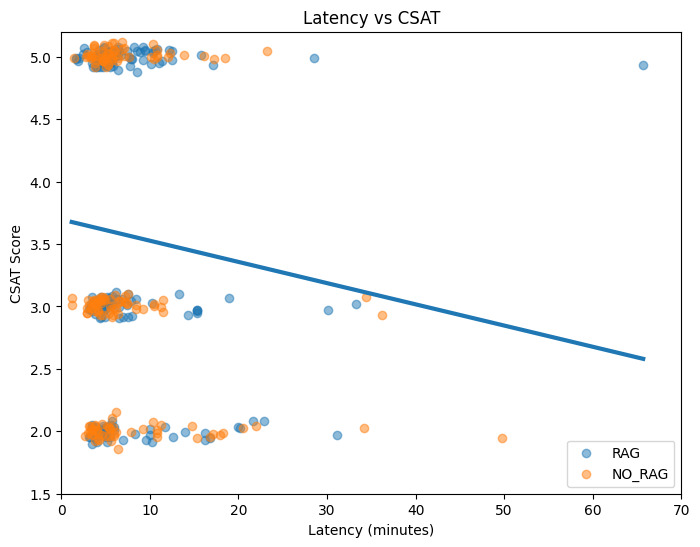

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(
    rag_data["latency_min"],
    rag_data["csat_score"] + np.random.normal(0, 0.05, len(rag_data)),
    alpha=0.5,
    label="RAG"
)

plt.scatter(
    no_rag_data["latency_min"],
    no_rag_data["csat_score"] + np.random.normal(0, 0.05, len(no_rag_data)),
    alpha=0.5,
    label="NO_RAG"
)

# Linear regression
z = np.polyfit(
    df_analysis["latency_min"],
    df_analysis["csat_score"],
    1
)

p = np.poly1d(z)

# Sort X values
x_sorted = np.sort(
    df_analysis["latency_min"]
)

plt.plot(
    x_sorted,
    p(x_sorted),
    linewidth=3
)

plt.title("Latency vs CSAT")
plt.xlabel("Latency (minutes)")
plt.ylabel("CSAT Score")

plt.xlim(0, 70)
plt.ylim(1.5, 5.2)

plt.legend()

plt.show()

Latencia vs CSAT

Objetivo:
Analizar la relación entre el tiempo de respuesta del sistema y el nivel de satisfacción percibido por los usuarios.

Insight:
Los resultados muestran una ligera tendencia negativa entre la latencia y el CSAT, indicando que mayores tiempos de respuesta tienden a relacionarse con menores niveles de satisfacción. Sin embargo, la distribución de los datos evidencia que los usuarios continúan otorgando niveles altos de satisfacción incluso en algunos casos con latencias elevadas, sugiriendo que la calidad de las recomendaciones puede compensar parcialmente el impacto del tiempo de respuesta.